In [1]:
import os
import cv2
from tqdm import tqdm
import numpy as np
from scipy import ndimage
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from scipy.ndimage import zoom
from sklearn.utils import shuffle
from scipy import signal
from xgboost import XGBClassifier
import pickle
from skimage.filters import threshold_otsu
from skimage.segmentation import clear_border
from skimage.morphology import closing, square
from scipy import ndimage
import matplotlib.patches as mpatches
from skimage.color import label2rgb
from skimage.measure import label, regionprops,find_contours
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from skimage.draw import polygon_perimeter

# Define the directories
dir_normal = 'C:\\Users\\yaswa\\learn\\Neural_networks\\research_ws\\Brain_ct_scan\\mal_dataset_thick\\mal_normal'
dir_thin = 'C:\\Users\\yaswa\\learn\\Neural_networks\\research_ws\\Brain_ct_scan\\mal_dataset_thick\\mal_acute'
dir_chronic = 'C:\\Users\\yaswa\\learn\\Neural_networks\\research_ws\\Brain_ct_scan\\mal_dataset_thick\\mal_chronic'

dir_train='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train'
dir_test='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test'

def preprocessing(im1):
    im1[im1==255]=0
    im2 = cv2.medianBlur(im1,51)
    th,img2=cv2.threshold(im2, 10, 255, cv2.THRESH_BINARY)
    img2[img2==255]=1
    image=np.multiply(img2,im1)
    thresh = threshold_otsu(image)
    bw = closing(image > thresh, square(3))
    cleared = clear_border(bw)
    label_image = label(cleared)
    image_label_overlay = label2rgb(label_image, image=image, bg_label=0)
    contours = find_contours(image, 0.8)
    bounding_boxes = []
    
    for contour in contours:
        Xmin = np.min(contour[:,0])
        Xmax = np.max(contour[:,0])
        Ymin = np.min(contour[:,1])
        Ymax = np.max(contour[:,1])

        bounding_boxes.append([Xmin, Xmax, Ymin, Ymax])

    with_boxes  = np.copy(image)

    for box in bounding_boxes:
        #[Xmin, Xmax, Ymin, Ymax]
        r = [box[0],box[1],box[1],box[0], box[0]]
        c = [box[3],box[3],box[2],box[2], box[3]]
        rr, cc = polygon_perimeter(r, c, with_boxes.shape)
        with_boxes[rr, cc] = 5 #set color white
        
    #fig, ax = plt.subplots(figsize=(10, 6))
    poly=[]
    
    for region in regionprops(label_image):
        # take regions with large enough areas
        if region.area >= 10000:
                # draw rectangle around segmented coins
            minr, minc, maxr, maxc = region.bbox
            rect = mpatches.Rectangle((minc, minr), maxc - minc, maxr - minr,
                                          fill=False, edgecolor='red', linewidth=2)
            poly.append(region.bbox)
            #ax.add_patch(rect)

    try:
        a,b,c,d=poly[-1]
        return cv2.resize(image[a:c,b:d], (512,512), interpolation= cv2.INTER_LINEAR)
    except IndexError:
        return cv2.resize(image, (512,512), interpolation= cv2.INTER_LINEAR)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

import numpy as np
from math import atan2, pi, atan

def steerable_pyramid(image, levels, orientations):
    if isinstance(image, tuple):
        height, width = image[0].shape[:2]
    else:
        height, width = image.shape[:2]
    pyramid = []

    for level in range(levels):
        pyramid_level = []
        for orientation in range(orientations):
            theta = orientation * np.pi / orientations

            # Create a filter at the specified orientation
            try:
                filt = steerable_filter(height, width, theta)
            except ValueError:
                continue

            # Convolve the image with the filter
            response = signal.convolve2d(image, filt, mode='same', boundary='symm')

            # Downsample the response
            response = zoom(response, 0.5)

            pyramid_level.append(response)

        pyramid.append(pyramid_level)
        image = zoom(image, 0.5)

    return pyramid

def steerable_filter(height, width, theta):
    sigma = 3
    gamma = 1
    scale = 1

    # Create Gaussian derivative filters
    gauss = signal.gaussian(height, std=sigma)
    gauss_d = np.gradient(gauss)

    # Construct the filter at the specified orientation
    x, y = np.meshgrid(np.arange(width), np.arange(height))
    x = x - (width - 1) / 2
    y = y - (height - 1) / 2
    x_theta = x * np.cos(theta) + y * np.sin(theta)
    y_theta = -x * np.sin(theta) + y * np.cos(theta)
    r_theta = np.sqrt(x_theta**2 + y_theta**2)
    filt = scale * np.exp(-0.5 * ((r_theta**2) / (sigma**2))**gamma) * np.cos(r_theta - theta)

    # Normalize the filter
    filt /= np.sum(np.abs(filt))

    return filt

def wld_descriptor(image, num_neighbors=8, num_orientations=8,num_diff_exc_bins=None, num_segments=6, num_bins_per_segment=3):
    """
    Compute the Weber Local Descriptor (WLD) for the given image.
    
    Args:
        image (numpy.ndarray): Input image.
        num_neighbors (int): Number of neighbors to consider for differential excitation.
        num_orientations (int): Number of dominant orientations to quantize the gradients.
        
    Returns:
        numpy.ndarray: WLD descriptor histogram.
    """
    # Compute differential excitation
    diff_excitation = differential_excitation(image, num_neighbors)
    segment_min = diff_excitation.min()
    segment_max = diff_excitation.max()
    segment_bins = np.linspace(segment_min, segment_max, endpoint=True)
    diff_excitation_hist, _ = np.histogram(diff_excitation, bins=segment_bins, density=True)
    
    # Compute orientation
    orientation = structure_tensor_orientation(image, num_orientations)
    segment_min = orientation.min()
    segment_max = orientation.max()
    segment_bins = np.linspace(segment_min, segment_max, endpoint=True)
    orientation_hist, _ = np.histogram(orientation, bins=segment_bins, density=True)
    
    diff_excitation = np.nan_to_num(diff_excitation, nan=0.0)

    # Set default value for num_diff_exc_bins if None
    num_diff_exc_bins = int(np.max(diff_excitation) - np.min(diff_excitation)) + 1
    # Combine differential excitation and orientation into the WLD descriptor histogram
    if num_diff_exc_bins is None:
        num_diff_exc_bins = int(np.max(diff_excitation) - np.min(diff_excitation)) + 1
    num_orientations=8
    #print('check 1',num_orientations)
    wld_2d_hist = np.zeros((num_diff_exc_bins, num_orientations))
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            j = int(diff_excitation[y, x])
            t = int(orientation[y, x])
            try:
                wld_2d_hist[j, t] += 1
            except IndexError:
                continue

    # Encode the 2D histogram into the 1D histogram H
    wld_1d_hist = encode_2d_to_1d_histogram(wld_2d_hist, num_segments, num_bins_per_segment)

    return np.array(np.ravel(wld_2d_hist))

def encode_2d_to_1d_histogram(wld_2d_hist, num_segments, num_bins_per_segment):
    """
    Encode the 2D WLD histogram into a 1D histogram.

    Args:
        wld_2d_hist (numpy.ndarray): 2D WLD histogram.
        num_segments (int): Number of segments to divide the differential excitation range.
        num_bins_per_segment (int): Number of bins within each differential excitation segment.

    Returns:
        numpy.ndarray: 1D WLD descriptor histogram.
    """
    num_orientations = wld_2d_hist.shape[1]
    diff_exc_range = np.pi
    segment_width = diff_exc_range / num_segments

    # Divide each column (orientation) into segments and concatenate
    wld_1d_hist = []
    for t in range(num_orientations):
        column_hist = wld_2d_hist[:, t]
        segments = np.array_split(column_hist, num_segments)
        segment_min = np.min(np.ravel(wld_2d_hist))
        segment_max = np.max(np.ravel(wld_2d_hist))
        for segment in segments:
            if segment.size > 0:  # Check if segment is not empty
                segment_bins = np.linspace(segment_min, segment_max, num_bins_per_segment + 1, endpoint=True)
                segment_hist, _ = np.histogram(segment, bins=segment_bins, density=True)
                segment_hist[np.isnan(segment_hist)] = 0  # Replace NaN values with 0
                segment_hist[np.isinf(segment_hist)] = 0
                wld_1d_hist.extend(segment_hist)
            else:
                # If segment is empty, assign default values to the corresponding bins
                wld_1d_hist.extend([0.0] * num_bins_per_segment)

    return np.array(wld_1d_hist)

def differential_excitation(image, num_neighbors):
    """
    Compute the differential excitation component of the WLD descriptor.
    
    Args:
        image (numpy.ndarray): Input image.
        num_neighbors (int): Number of neighbors to consider.
        
    Returns:
        numpy.ndarray: Differential excitation values.
    """
    diff_excitation = np.zeros_like(image, dtype=np.float64)
    image=np.asarray(image)
    print(image.shape[0])
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            neighbors = []
            for dy in [-1, 0, 1]:
                for dx in [-1, 0, 1]:
                    if dy == dx == 0:
                        continue
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < image.shape[0] and 0 <= nx < image.shape[1]:
                        neighbors.append(image[ny, nx])
            neighbors = np.array(neighbors)
            diff_excitation[y, x] = np.arctan(np.sum(neighbors - image[y, x]) / (image[y, x]+1e-6))
    return diff_excitation

def structure_tensor_orientation(image, num_orientations=8,window_size=3, sigma=1.0):
    """
    Compute the orientation component of the WLD descriptor using the structure tensor approach.

    Args:
        image (numpy.ndarray): Input image.
        window_size (int): Size of the local neighborhood window for computing the structure tensor.
        sigma (float): Standard deviation for Gaussian kernel used for smoothing.

    Returns:
        numpy.ndarray: Orientations computed using the structure tensor.
    """
    # Compute gradients
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

    # Compute structure tensor components
    ix2 = sobel_x ** 2
    iy2 = sobel_y ** 2
    ixy = sobel_x * sobel_y

    # Smooth the structure tensor components
    kernel = cv2.getGaussianKernel(window_size, sigma)
    ix2 = cv2.sepFilter2D(ix2, -1, kernel, kernel)
    iy2 = cv2.sepFilter2D(iy2, -1, kernel, kernel)
    ixy = cv2.sepFilter2D(ixy, -1, kernel, kernel)

    # Compute eigenvalues and orientations
    orientation = np.zeros_like(image, dtype=np.float64)
    num_orientations=8
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            tensor = np.array([[ix2[y, x], ixy[y, x]], [ixy[y, x], iy2[y, x]]])
            eigenvalues, eigenvectors = np.linalg.eig(tensor)
            orientation[y, x] = np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0])
    
    if num_orientations is not None:
        orientation = (orientation % (2 * pi)) * num_orientations / (2 * pi)
        return orientation.astype(int)
    else:
        return orientation


def get_label(dir):
    if 'NS' in dir:
        return 0
    elif 'AS' in dir:
        return 1
    elif 'CS' in dir:
        return 2
    
def resize_image(image, target_size=(512, 512)):
    resized_image = cv2.resize(image, target_size)
    return resized_image

def extract_patches(image, patch_size):
    patches = []
    height, width = image.shape[:2]
    for y in range(0, height - patch_size[0] + 1, patch_size[0]):
        for x in range(0, width - patch_size[1] + 1, patch_size[1]):
            patch = image[y:y+patch_size[0], x:x+patch_size[1]]
            patches.append(patch)
    return np.array(patches)

def wld_descriptor_multiscale(image, num_orientations, num_diff_exc_bins, num_segments, num_bins_per_segment, num_scales):
    """
    Compute the Weber Local Descriptor (WLD) for the given image at multiple scales.

    Args:
        image (numpy.ndarray): Input image.
        num_orientations (int): Number of dominant orientations to quantize.
        num_diff_exc_bins (int, optional): Number of bins for differential excitation values.
            If None, it is set to the maximum intensity value in the image.
        num_segments (int): Number of segments to divide the differential excitation range.
        num_bins_per_segment (int): Number of bins within each differential excitation segment.
        num_scales (int): Number of scales to compute the WLD descriptor.

    Returns:
        numpy.ndarray: 1D concatenated multi-scale WLD descriptor histogram.
    """
    # Create a Gaussian pyramid for the input image
    '''
    pyramid = [image.astype(np.float32)]  # Add the original image as the first level
    for _ in range(num_scales - 1):
        pyramid.append(cv2.pyrDown(pyramid[-1]))
    '''
    pyramid = steerable_pyramid(image, levels=2, orientations=5)
    # Compute WLD descriptor at each scale and concatenate
    wld_descriptors = []
    for img in pyramid:
        #print('check',num_orientations)
        wld_descriptors.append(wld_descriptor(img, num_orientations, num_diff_exc_bins, num_segments, num_bins_per_segment))

    wld_multiscale = np.concatenate(wld_descriptors)
    return wld_multiscale

def ltp_descriptor(image, radius=3, neighbors=8, threshold=5):
    """
    Compute the Local Ternary Pattern (LTP) descriptor.

    Args:
        image (numpy.ndarray): Input image.
        radius (int): Radius of the neighborhood.
        neighbors (int): Number of neighbors to consider.
        threshold (int): Threshold value for ternary coding.

    Returns:
        numpy.ndarray: LTP descriptor histogram.
    """
    ltp_hist = np.zeros(3 ** neighbors, dtype=np.uint8)
    for y in range(radius, image.shape[0] - radius):
        for x in range(radius, image.shape[1] - radius):
            center = image[y, x]
            code = 0
            for n in range(neighbors):
                x_offset = x + radius * np.cos(2 * pi * n / neighbors)
                y_offset = y - radius * np.sin(2 * pi * n / neighbors)
                neighbor = image[int(y_offset), int(x_offset)]
                code = code * 3 + (neighbor >= center + threshold) + (neighbor <= center - threshold)
            ltp_hist[code] += 1
    return ltp_hist

def lbp_descriptor(image, radius=3, neighbors=8):
    """
    Compute the Local Binary Pattern (LBP) descriptor.

    Args:
        image (numpy.ndarray): Input image.
        radius (int): Radius of the neighborhood.
        neighbors (int): Number of neighbors to consider.

    Returns:
        numpy.ndarray: LBP descriptor histogram.
    """
    lbp_hist = np.zeros(2 ** neighbors, dtype=np.uint8)
    for y in range(radius, image.shape[0] - radius):
        for x in range(radius, image.shape[1] - radius):
            center = image[y, x]
            code = 0
            for n in range(neighbors):
                x_offset = x + radius * np.cos(2 * pi * n / neighbors)
                y_offset = y - radius * np.sin(2 * pi * n / neighbors)
                neighbor = image[int(y_offset), int(x_offset)]
                code = code * 2 + (neighbor >= center)
            lbp_hist[code] += 1
    return lbp_hist

def fused_descriptor(image, num_orientations=8, num_diff_exc_bins=None, num_segments=6, num_bins_per_segment=3, ltp_radius=3, num_scales=5,ltp_neighbors=8, ltp_threshold=5, lbp_radius=3, lbp_neighbors=8):
    """
    Compute a fused descriptor combining WLD, LTP, and LBP.

    Args:
        image (numpy.ndarray): Input image.
        num_orientations (int): Number of dominant orientations for WLD.
        num_diff_exc_bins (int, optional): Number of bins for differential excitation values in WLD.
        num_segments (int): Number of segments for differential excitation in WLD.
        num_bins_per_segment (int): Number of bins within each differential excitation segment in WLD.
        ltp_radius (int): Radius of the neighborhood for LTP.
        ltp_neighbors (int): Number of neighbors to consider for LTP.
        ltp_threshold (int): Threshold value for ternary coding in LTP.
        lbp_radius (int): Radius of the neighborhood for LBP.
        lbp_neighbors (int): Number of neighbors to consider for LBP.

    Returns:
        numpy.ndarray: Fused descriptor combining WLD, LTP, and LBP.
    """
    # Compute WLD descriptor
    wld_descriptor = wld_descriptor_multiscale(image, num_orientations, num_diff_exc_bins, num_segments,num_scales, num_bins_per_segment)

    # Compute LTP descriptor
    ltp_descriptor_hist = ltp_descriptor(image, ltp_radius, ltp_neighbors, ltp_threshold)

    # Compute LBP descriptor
    lbp_descriptor_hist = lbp_descriptor(image, lbp_radius, lbp_neighbors)

    # Concatenate WLD, LTP, and LBP descriptors
    fused_descriptor_hist = np.concatenate((wld_descriptor, ltp_descriptor_hist, lbp_descriptor_hist))

    return wld_descriptor,fused_descriptor_hist

image=criptor(image, num_orientations=8, num_diff_exc_bins=None, num_segments=6, num_bins_per_segment=3, ltp_radius=3, num_scales=5,ltp_neighbors=8, ltp_threshold=5, lbp_radius=3, lbp_neighbors=8)

'''
dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train'
folders=np.random.choice(os.listdir(dirpath),40)
images=[]
X_train=np.zeros(shape=(100,512,512))
y_train=[]
c=0
while c<=100:
    if c>100:
        break
    n=np.random.choice(folders,1)
    img=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
    X_train[c,:]=wld_descriptor_multiscale(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))),
                                           num_neighbors=8, num_orientations=8,num_diff_exc_bins=None, num_segments=6, num_bins_per_segment=3)
    y_train.append(get_label(n[0]))
    c+=1
'''

TypeError: wld_descriptor_multiscale() got an unexpected keyword argument 'num_neighbors'

In [ ]:
dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test'
folders=np.random.choice(os.listdir(dirpath),10)
images=[]
X_test=np.zeros(shape=(100,512,512))
y_test=[]
c=0
while c<=100:
    if c>100:
        break
    n=np.random.choice(folders,1)
    img=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
    X_train[c,:]=wld_descriptor_multiscale(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))),
                                           num_neighbors=8, num_orientations=8,num_diff_exc_bins=None, num_segments=6, num_bins_per_segment=3)
    y_train.append(get_label(n[0]))
    c+=1
    

In [ ]:
Wavelet Pyramid 

In [102]:
import pywt
def wavelet_pyramid(image, levels=3, wavelet='haar'):
    pyramid = []
    wld_descriptors=[]

    # Apply wavelet transform at each level
    for _ in range(levels):
        coeffs = pywt.dwt2(image, wavelet)
        pyramid.append(coeffs)
        image, _ = coeffs

        # Add the coarsest approximation at the end
    return pyramid
'''
def reconstruct_from_pyramid(pyramid, wavelet='haar'):
    # Reconstruct the image from the pyramid
    image = pyramid[-1]
    for level in reversed(pyramid[:-1]):
        image = pywt.idwt2((image, level[1]), wavelet)

    return image

# Example usage
img=preprocessing(resize_image(cv2.imread('C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train/AS_01_thin/Anonymize.Seq3.Ser202.Img145.jpg',0),(512,512)))
levels = 3  # Number of pyramid levels
wavelet = 'haar'  # Wavelet type

# Construct the wavelet pyramid
pyramid = wavelet_pyramid(img, levels, wavelet)

# Reconstruct the image from the pyramid
reconstructed_image = reconstruct_from_pyramid(pyramid, wavelet)

# Check reconstruction error (should be close to zero)
reconstruction_error = np.linalg.norm(img - reconstructed_image)
print("Reconstruction error:", reconstruction_error)
'''

'\ndef reconstruct_from_pyramid(pyramid, wavelet=\'haar\'):\n    # Reconstruct the image from the pyramid\n    image = pyramid[-1]\n    for level in reversed(pyramid[:-1]):\n        image = pywt.idwt2((image, level[1]), wavelet)\n\n    return image\n\n# Example usage\nimg=preprocessing(resize_image(cv2.imread(\'C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train/AS_01_thin/Anonymize.Seq3.Ser202.Img145.jpg\',0),(512,512)))\nlevels = 3  # Number of pyramid levels\nwavelet = \'haar\'  # Wavelet type\n\n# Construct the wavelet pyramid\npyramid = wavelet_pyramid(img, levels, wavelet)\n\n# Reconstruct the image from the pyramid\nreconstructed_image = reconstruct_from_pyramid(pyramid, wavelet)\n\n# Check reconstruction error (should be close to zero)\nreconstruction_error = np.linalg.norm(img - reconstructed_image)\nprint("Reconstruction error:", reconstruction_error)\n'

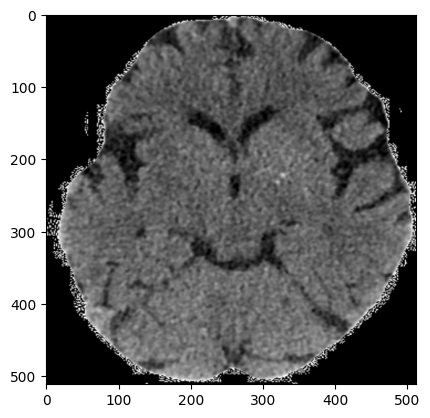

In [170]:
def preprocessing(im1):
    im1[im1==255]=0
    im2 = cv2.medianBlur(im1,51)
    th,img2=cv2.threshold(im2, 10, 255, cv2.THRESH_BINARY)
    img2[img2==255]=1
    image=np.multiply(img2,im1)
    thresh = threshold_otsu(image)
    bw = closing(image > thresh, square(3))
    cleared = clear_border(bw)
    label_image = label(cleared)
    image_label_overlay = label2rgb(label_image, image=image, bg_label=0)
    contours = find_contours(image, 0.8)
    bounding_boxes = []
    
    for contour in contours:
        Xmin = np.min(contour[:,0])
        Xmax = np.max(contour[:,0])
        Ymin = np.min(contour[:,1])
        Ymax = np.max(contour[:,1])

        bounding_boxes.append([Xmin, Xmax, Ymin, Ymax])

    with_boxes  = np.copy(image)

    for box in bounding_boxes:
        #[Xmin, Xmax, Ymin, Ymax]
        r = [box[0],box[1],box[1],box[0], box[0]]
        c = [box[3],box[3],box[2],box[2], box[3]]
        rr, cc = polygon_perimeter(r, c, with_boxes.shape)
        with_boxes[rr, cc] = 5 #set color white
        
    #fig, ax = plt.subplots(figsize=(10, 6))
    poly=[]
    
    for region in regionprops(label_image):
        # take regions with large enough areas
        if region.area >= 10000:
                # draw rectangle around segmented coins
            minr, minc, maxr, maxc = region.bbox
            rect = mpatches.Rectangle((minc, minr), maxc - minc, maxr - minr,
                                          fill=False, edgecolor='red', linewidth=2)
            poly.append(region.bbox)
            #ax.add_patch(rect)

    try:
        a,b,c,d=poly[-1]
        return cv2.resize(image[a:c,b:d], (512,512), interpolation= cv2.INTER_LINEAR)
    except IndexError:
        return cv2.resize(image, (512,512), interpolation= cv2.INTER_LINEAR)

def get_label(dir):
    if 'NS' in dir:
        return 0
    elif 'AS' in dir:
        return 1
    elif 'CS' in dir:
        return 2
    
def resize_image(image, target_size=(512, 512)):
    resized_image = cv2.resize(image, target_size)
    return resized_image

def extract_patches(image, patch_size):
    patches = []
    height, width = image.shape[:2]
    for y in range(0, height - patch_size[0] + 1, patch_size[0]):
        for x in range(0, width - patch_size[1] + 1, patch_size[1]):
            patch = image[y:y+patch_size[0], x:x+patch_size[1]]
            patches.append(patch)
    return np.array(patches)

def wld_descriptor_mod(image, num_neighbors=8, num_orientations=8,num_diff_exc_bins=None, num_segments=6, num_bins_per_segment=3):
    """
    Compute the Weber Local Descriptor (WLD) for the given image.
    
    Args:
        image (numpy.ndarray): Input image.
        num_neighbors (int): Number of neighbors to consider for differential excitation.
        num_orientations (int): Number of dominant orientations to quantize the gradients.
        
    Returns:
        numpy.ndarray: WLD descriptor histogram.
    """
    # Compute differential excitation
    diff_excitation = differential_excitation(image, num_neighbors)
    segment_min = diff_excitation.min()
    segment_max = diff_excitation.max()
    segment_bins = np.linspace(segment_min, segment_max, endpoint=True)
    diff_excitation_hist, _ = np.histogram(diff_excitation, bins=segment_bins, density=True)
    
    # Compute orientation
    orientation = structure_tensor_orientation(image, num_orientations=8,window_size=3, sigma=1.0)
    segment_min = orientation.min()
    segment_max = orientation.max()
    segment_bins = np.linspace(segment_min, segment_max, endpoint=True)
    orientation_hist, _ = np.histogram(orientation, bins=segment_bins, density=True)
    
    diff_excitation = np.nan_to_num(diff_excitation, nan=0.0)

    # Set default value for num_diff_exc_bins if None
    num_diff_exc_bins = int(np.max(diff_excitation) - np.min(diff_excitation)) + 1
    # Combine differential excitation and orientation into the WLD descriptor histogram
    if num_diff_exc_bins is None:
        num_diff_exc_bins = int(np.max(diff_excitation) - np.min(diff_excitation)) + 1
    num_orientations=8
    wld_2d_hist = np.zeros((num_diff_exc_bins, num_orientations))
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            j = int(diff_excitation[y, x])
            t = int(orientation[y, x])
            wld_2d_hist[j, t] += 1

    # Encode the 2D histogram into the 1D histogram H
    wld_1d_hist = encode_2d_to_1d_histogram(wld_2d_hist, num_segments, num_bins_per_segment)

    return np.array(np.ravel(wld_2d_hist))

def encode_2d_to_1d_histogram(wld_2d_hist, num_segments, num_bins_per_segment):
    """
    Encode the 2D WLD histogram into a 1D histogram.

    Args:
        wld_2d_hist (numpy.ndarray): 2D WLD histogram.
        num_segments (int): Number of segments to divide the differential excitation range.
        num_bins_per_segment (int): Number of bins within each differential excitation segment.

    Returns:
        numpy.ndarray: 1D WLD descriptor histogram.
    """
    num_orientations = wld_2d_hist.shape[1]
    diff_exc_range = np.pi
    segment_width = diff_exc_range / num_segments

    # Divide each column (orientation) into segments and concatenate
    wld_1d_hist = []
    for t in range(num_orientations):
        column_hist = wld_2d_hist[:, t]
        segments = np.array_split(column_hist, num_segments)
        segment_min = np.min(np.ravel(wld_2d_hist))
        segment_max = np.max(np.ravel(wld_2d_hist))
        for segment in segments:
            if segment.size > 0:  # Check if segment is not empty
                segment_bins = np.linspace(segment_min, segment_max, num_bins_per_segment + 1, endpoint=True)
                segment_hist, _ = np.histogram(segment, bins=segment_bins, density=True)
                segment_hist[np.isnan(segment_hist)] = 0  # Replace NaN values with 0
                segment_hist[np.isinf(segment_hist)] = 0
                wld_1d_hist.extend(segment_hist)
            else:
                # If segment is empty, assign default values to the corresponding bins
                wld_1d_hist.extend([0.0] * num_bins_per_segment)

    return np.array(wld_1d_hist)

def differential_excitation(image, num_neighbors):
    """
    Compute the differential excitation component of the WLD descriptor.
    
    Args:
        image (numpy.ndarray): Input image.
        num_neighbors (int): Number of neighbors to consider.
        
    Returns:
        numpy.ndarray: Differential excitation values.
    """
    diff_excitation = np.zeros_like(image, dtype=np.float64)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            neighbors = []
            for dy in [-1, 0, 1]:
                for dx in [-1, 0, 1]:
                    if dy == dx == 0:
                        continue
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < image.shape[0] and 0 <= nx < image.shape[1]:
                        neighbors.append(image[ny, nx])
            neighbors = np.array(neighbors)
            diff_excitation[y, x] = np.arctan(np.sum(neighbors - image[y, x]) / (image[y, x]+1e-6))
    return diff_excitation

def structure_tensor_orientation(image, num_orientations=8,window_size=3, sigma=1.0):
    """
    Compute the orientation component of the WLD descriptor using the structure tensor approach.

    Args:
        image (numpy.ndarray): Input image.
        window_size (int): Size of the local neighborhood window for computing the structure tensor.
        sigma (float): Standard deviation for Gaussian kernel used for smoothing.

    Returns:
        numpy.ndarray: Orientations computed using the structure tensor.
    """
    # Compute gradients
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

    # Compute structure tensor components
    ix2 = sobel_x ** 2
    iy2 = sobel_y ** 2
    ixy = sobel_x * sobel_y

    # Smooth the structure tensor components
    kernel = cv2.getGaussianKernel(window_size, sigma)
    ix2 = cv2.sepFilter2D(ix2, -1, kernel, kernel)
    iy2 = cv2.sepFilter2D(iy2, -1, kernel, kernel)
    ixy = cv2.sepFilter2D(ixy, -1, kernel, kernel)

    # Compute eigenvalues and orientations
    orientation = np.zeros_like(image, dtype=np.float64)
    num_orientations=8
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            tensor = np.array([[ix2[y, x], ixy[y, x]], [ixy[y, x], iy2[y, x]]])
            eigenvalues, eigenvectors = np.linalg.eig(tensor)
            orientation[y, x] = np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0])
    
    if num_orientations is not None:
        orientation = (orientation % (2 * pi)) * num_orientations / (2 * pi)
        return orientation.astype(int)
    else:
        return orientation.astype(int)

def wld_descriptor_multiscale(image, num_orientations=8, num_diff_exc_bins=None, num_segments=6, num_bins_per_segment=3, num_scales=4):
    """
    Compute the Weber Local Descriptor (WLD) for the given image at multiple scales.

    Args:
        image (numpy.ndarray): Input image.
        num_orientations (int): Number of dominant orientations to quantize.
        num_diff_exc_bins (int, optional): Number of bins for differential excitation values.
            If None, it is set to the maximum intensity value in the image.
        num_segments (int): Number of segments to divide the differential excitation range.
        num_bins_per_segment (int): Number of bins within each differential excitation segment.
        num_scales (int): Number of scales to compute the WLD descriptor.

    Returns:
        numpy.ndarray: 1D concatenated multi-scale WLD descriptor histogram.
    """
    # Create a Gaussian pyramid for the input image
    pyramid = [image.astype(np.float32)]  # Add the original image as the first level
    for _ in range(num_scales - 1):
        pyramid.append(cv2.pyrDown(pyramid[-1]))

    # Compute WLD descriptor at each scale and concatenate
    wld_descriptors = []
    for img in pyramid:
        #print('check',num_orientations)
        wld_descriptors.append(wld_descriptor_mod(image, num_orientations, num_diff_exc_bins, num_segments, num_bins_per_segment))

    wld_multiscale = np.concatenate(wld_descriptors)
    return pyramid

img=preprocessing(resize_image(cv2.imread('C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train/AS_01_thin/Anonymize.Seq3.Ser202.Img145.jpg',0),(512,512)))
W=wld_descriptor_multiscale(img, num_orientations=8, num_diff_exc_bins=None, num_segments=6, num_bins_per_segment=3, num_scales=4)
plt.imshow(W[0],cmap='gray')

In [174]:
plt.imshow(W[4],cmap='gray')

IndexError: list index out of range

In [2]:
dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train'
folders=np.random.choice(os.listdir(dirpath),40)
images=[]
X_train=np.zeros(shape=(200,96))
y_train=[]
c=0
for c in range(200):
    n=np.random.choice(folders,1)
    img=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
    pyramid=wavelet_pyramid(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
    extracted_images = [level[0] for level in pyramid]
    wld_descriptors=[]
    a,b=0,0
    for i, extracted_image in enumerate(extracted_images):
            #print('check',num_orientations)
        if len(np.shape(extracted_image))!=2:
            continue
        else:
            w=wld_descriptor(extracted_image, num_neighbors=8, num_orientations=5,num_diff_exc_bins=None, num_segments=10, num_bins_per_segment=3)
            X_train[c,a:a+len(w)]=w
            a=len(w)
    y_train.append(n[0])


NameError: name 'wavelet_pyramid' is not defined

In [157]:
dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test'
folders=np.random.choice(os.listdir(dirpath),10)
images=[]
X_test=np.zeros(shape=(50,96))
y_test=[]
c=0
for i in range(50):
    n=np.random.choice(folders,1)
    img=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
    pyramid=wavelet_pyramid(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
    extracted_images = [level[0] for level in pyramid]
    for i, extracted_image in enumerate(extracted_images):
        wld_descriptors=[]
            #print('check',num_orientations)
        if len(np.shape(extracted_image))!=2:
            continue
        else:
            w=wld_descriptor(extracted_image, num_neighbors=8, num_orientations=5,num_diff_exc_bins=None, num_segments=10, num_bins_per_segment=3)
            X_test[c,a:a+len(w)]=w
            a=len(w)
    y_test.append(n[0])

256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64
256
128
64


In [59]:
wld_descriptors = []
for i, extracted_image in enumerate(extracted_images):
    print(f"Shape of image at level {i}: {extracted_image.shape}")
        #print('check',num_orientations)
    if len(np.shape(extracted_image))!=2:
        continue
    else:
        print('sdiv',np.shape(wld_descriptors))
        wld_descriptors.append(wld_descriptor(extracted_image, num_neighbors=8, num_orientations=8,num_diff_exc_bins=None, num_segments=6, num_bins_per_segment=3))

Shape of image at level 0: (256, 256)
sdiv (0,)
256
Shape of image at level 1: (128, 128)
sdiv (1, 32)
128
Shape of image at level 2: (64, 64)
sdiv (2, 32)
64
Shape of image at level 3: (64,)


In [159]:
from lazypredict.Supervised import LazyClassifier

clf = LazyClassifier(verbose=0,ignore_warnings=False, custom_metric=None)
models,predictions = clf.fit(X_train, X_test, y_Train, y_Test)

print(models)

 21%|█████████████████▏                                                                 | 6/29 [00:00<00:00, 33.45it/s]

ROC AUC couldn't be calculated for AdaBoostClassifier
multi_class must be in ('ovo', 'ovr')
ROC AUC couldn't be calculated for BaggingClassifier
multi_class must be in ('ovo', 'ovr')
ROC AUC couldn't be calculated for BernoulliNB
multi_class must be in ('ovo', 'ovr')
ROC AUC couldn't be calculated for CalibratedClassifierCV
multi_class must be in ('ovo', 'ovr')
CategoricalNB model failed to execute
Negative values in data passed to CategoricalNB (input X)
ROC AUC couldn't be calculated for DecisionTreeClassifier
multi_class must be in ('ovo', 'ovr')
ROC AUC couldn't be calculated for DummyClassifier
multi_class must be in ('ovo', 'ovr')
ROC AUC couldn't be calculated for ExtraTreeClassifier
multi_class must be in ('ovo', 'ovr')


 48%|███████████████████████████████████████▌                                          | 14/29 [00:00<00:00, 33.71it/s]

ROC AUC couldn't be calculated for ExtraTreesClassifier
multi_class must be in ('ovo', 'ovr')
ROC AUC couldn't be calculated for GaussianNB
multi_class must be in ('ovo', 'ovr')
ROC AUC couldn't be calculated for KNeighborsClassifier
multi_class must be in ('ovo', 'ovr')
ROC AUC couldn't be calculated for LabelPropagation
multi_class must be in ('ovo', 'ovr')
ROC AUC couldn't be calculated for LabelSpreading
multi_class must be in ('ovo', 'ovr')
ROC AUC couldn't be calculated for LinearDiscriminantAnalysis
multi_class must be in ('ovo', 'ovr')
ROC AUC couldn't be calculated for LinearSVC
multi_class must be in ('ovo', 'ovr')
ROC AUC couldn't be calculated for LogisticRegression
multi_class must be in ('ovo', 'ovr')
ROC AUC couldn't be calculated for NearestCentroid
multi_class must be in ('ovo', 'ovr')
NuSVC model failed to execute
specified nu is infeasible
ROC AUC couldn't be calculated for PassiveAggressiveClassifier
multi_class must be in ('ovo', 'ovr')
ROC AUC couldn't be calculat

 76%|██████████████████████████████████████████████████████████████▏                   | 22/29 [00:00<00:00, 36.74it/s]

ROC AUC couldn't be calculated for QuadraticDiscriminantAnalysis
multi_class must be in ('ovo', 'ovr')
ROC AUC couldn't be calculated for RandomForestClassifier
multi_class must be in ('ovo', 'ovr')
ROC AUC couldn't be calculated for RidgeClassifier
multi_class must be in ('ovo', 'ovr')
ROC AUC couldn't be calculated for RidgeClassifierCV
multi_class must be in ('ovo', 'ovr')
ROC AUC couldn't be calculated for SGDClassifier
multi_class must be in ('ovo', 'ovr')
ROC AUC couldn't be calculated for SVC
multi_class must be in ('ovo', 'ovr')
StackingClassifier model failed to execute
__init__() missing 1 required positional argument: 'estimators'


 97%|███████████████████████████████████████████████████████████████████████████████▏  | 28/29 [00:00<00:00, 27.64it/s]

ROC AUC couldn't be calculated for XGBClassifier
multi_class must be in ('ovo', 'ovr')
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1685
[LightGBM] [Info] Number of data points in the train set: 200, number of used features: 36
[LightGBM] [Info] Start training from score -1.966113
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Info] Start training from score -1.021651
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:01<00:00, 20.45it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [148]:
np.shape(y_test),np.shape(y_train)

((50,), (200,))

In [89]:
import random as r
dir_train='C:/Users/mahesh.inamdar/Desktop/codes/Sets/Set 9010/train/'
r.shuffle(os.listdir(dir_train))

In [177]:
dir_train='C:/Users/mahesh.inamdar/Desktop/codes/Sets/Set 9010/train/'
dir_test='C:/Users/mahesh.inamdar/Desktop/codes/Sets/Set 9010/test/'

import os
import cv2
from tqdm import tqdm
import numpy as np
from scipy import ndimage
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils import shuffle
from xgboost import XGBClassifier
import pickle
from skimage.filters import threshold_otsu
from skimage.segmentation import clear_border
from skimage.morphology import closing, square
from scipy import ndimage
import matplotlib.patches as mpatches
from skimage.color import label2rgb
from skimage.measure import label, regionprops,find_contours
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from skimage.draw import polygon_perimeter
from math import atan2, pi, atan
from lazypredict.Supervised import LazyClassifier

def preprocessing(im1):
    im1[im1==255]=0
    im2 = cv2.medianBlur(im1,51)
    th,img2=cv2.threshold(im2, 10, 255, cv2.THRESH_BINARY)
    img2[img2==255]=1
    image=np.multiply(img2,im1)
    thresh = threshold_otsu(image)
    bw = closing(image > thresh, square(3))
    cleared = clear_border(bw)
    label_image = label(cleared)
    image_label_overlay = label2rgb(label_image, image=image, bg_label=0)
    contours = find_contours(image, 0.8)
    bounding_boxes = []
    
    for contour in contours:
        Xmin = np.min(contour[:,0])
        Xmax = np.max(contour[:,0])
        Ymin = np.min(contour[:,1])
        Ymax = np.max(contour[:,1])

        bounding_boxes.append([Xmin, Xmax, Ymin, Ymax])

    with_boxes  = np.copy(image)

    for box in bounding_boxes:
        #[Xmin, Xmax, Ymin, Ymax]
        r = [box[0],box[1],box[1],box[0], box[0]]
        c = [box[3],box[3],box[2],box[2], box[3]]
        rr, cc = polygon_perimeter(r, c, with_boxes.shape)
        with_boxes[rr, cc] = 5 #set color white
        
    #fig, ax = plt.subplots(figsize=(10, 6))
    poly=[]
    
    for region in regionprops(label_image):
        # take regions with large enough areas
        if region.area >= 10000:
                # draw rectangle around segmented coins
            minr, minc, maxr, maxc = region.bbox
            rect = mpatches.Rectangle((minc, minr), maxc - minc, maxr - minr,
                                          fill=False, edgecolor='red', linewidth=2)
            poly.append(region.bbox)
            #ax.add_patch(rect)

    try:
        a,b,c,d=poly[-1]
        return cv2.resize(image[a:c,b:d], (512,512), interpolation= cv2.INTER_LINEAR)
    except IndexError:
        return cv2.resize(image, (512,512), interpolation= cv2.INTER_LINEAR)

def get_label(dir):
    if 'NS' in dir:
        return 0
    elif 'AS' in dir:
        return 1
    elif 'CS' in dir:
        return 2
    
def resize_image(image, target_size=(512, 512)):
    resized_image = cv2.resize(image, target_size)
    return resized_image

def extract_patches(image, patch_size):
    patches = []
    height, width = image.shape[:2]
    for y in range(0, height - patch_size[0] + 1, patch_size[0]):
        for x in range(0, width - patch_size[1] + 1, patch_size[1]):
            patch = image[y:y+patch_size[0], x:x+patch_size[1]]
            patches.append(patch)
    return np.array(patches)

def wld_descriptor_mod(image, num_neighbors=8, num_orientations=8,num_diff_exc_bins=None, num_segments=6, num_bins_per_segment=3):
    """
    Compute the Weber Local Descriptor (WLD) for the given image.
    
    Args:
        image (numpy.ndarray): Input image.
        num_neighbors (int): Number of neighbors to consider for differential excitation.
        num_orientations (int): Number of dominant orientations to quantize the gradients.
        
    Returns:
        numpy.ndarray: WLD descriptor histogram.
    """
    # Compute differential excitation
    diff_excitation = differential_excitation(image, num_neighbors)
    segment_min = diff_excitation.min()
    segment_max = diff_excitation.max()
    segment_bins = np.linspace(segment_min, segment_max, endpoint=True)
    diff_excitation_hist, _ = np.histogram(diff_excitation, bins=segment_bins, density=True)
    
    # Compute orientation
    orientation = structure_tensor_orientation(image, num_orientations=8,window_size=3, sigma=1.0)
    segment_min = orientation.min()
    segment_max = orientation.max()
    segment_bins = np.linspace(segment_min, segment_max, endpoint=True)
    orientation_hist, _ = np.histogram(orientation, bins=segment_bins, density=True)
    
    diff_excitation = np.nan_to_num(diff_excitation, nan=0.0)

    # Set default value for num_diff_exc_bins if None
    num_diff_exc_bins = int(np.max(diff_excitation) - np.min(diff_excitation)) + 1
    # Combine differential excitation and orientation into the WLD descriptor histogram
    if num_diff_exc_bins is None:
        num_diff_exc_bins = int(np.max(diff_excitation) - np.min(diff_excitation)) + 1
    num_orientations=8
    wld_2d_hist = np.zeros((num_diff_exc_bins, num_orientations))
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            j = int(diff_excitation[y, x])
            t = int(orientation[y, x])
            wld_2d_hist[j, t] += 1

    # Encode the 2D histogram into the 1D histogram H
    wld_1d_hist = encode_2d_to_1d_histogram(wld_2d_hist, num_segments, num_bins_per_segment)

    return diff_excitation,orientation,np.array(np.ravel(wld_2d_hist))

def encode_2d_to_1d_histogram(wld_2d_hist, num_segments, num_bins_per_segment):
    """
    Encode the 2D WLD histogram into a 1D histogram.

    Args:
        wld_2d_hist (numpy.ndarray): 2D WLD histogram.
        num_segments (int): Number of segments to divide the differential excitation range.
        num_bins_per_segment (int): Number of bins within each differential excitation segment.

    Returns:
        numpy.ndarray: 1D WLD descriptor histogram.
    """
    num_orientations = wld_2d_hist.shape[1]
    diff_exc_range = np.pi
    segment_width = diff_exc_range / num_segments

    # Divide each column (orientation) into segments and concatenate
    wld_1d_hist = []
    for t in range(num_orientations):
        column_hist = wld_2d_hist[:, t]
        segments = np.array_split(column_hist, num_segments)
        segment_min = np.min(np.ravel(wld_2d_hist))
        segment_max = np.max(np.ravel(wld_2d_hist))
        for segment in segments:
            if segment.size > 0:  # Check if segment is not empty
                segment_bins = np.linspace(segment_min, segment_max, num_bins_per_segment + 1, endpoint=True)
                segment_hist, _ = np.histogram(segment, bins=segment_bins, density=True)
                segment_hist[np.isnan(segment_hist)] = 0  # Replace NaN values with 0
                segment_hist[np.isinf(segment_hist)] = 0
                wld_1d_hist.extend(segment_hist)
            else:
                # If segment is empty, assign default values to the corresponding bins
                wld_1d_hist.extend([0.0] * num_bins_per_segment)

    return np.array(wld_1d_hist)

def differential_excitation(image, num_neighbors):
    """
    Compute the differential excitation component of the WLD descriptor.
    
    Args:
        image (numpy.ndarray): Input image.
        num_neighbors (int): Number of neighbors to consider.
        
    Returns:
        numpy.ndarray: Differential excitation values.
    """
    diff_excitation = np.zeros_like(image, dtype=np.float64)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            neighbors = []
            for dy in [-1, 0, 1]:
                for dx in [-1, 0, 1]:
                    if dy == dx == 0:
                        continue
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < image.shape[0] and 0 <= nx < image.shape[1]:
                        neighbors.append(image[ny, nx])
            neighbors = np.array(neighbors)
            diff_excitation[y, x] = np.arctan(np.sum(neighbors - image[y, x]) / (image[y, x]+1e-6))
    return diff_excitation

def structure_tensor_orientation(image, num_orientations=8,window_size=3, sigma=1.0):
    """
    Compute the orientation component of the WLD descriptor using the structure tensor approach.

    Args:
        image (numpy.ndarray): Input image.
        window_size (int): Size of the local neighborhood window for computing the structure tensor.
        sigma (float): Standard deviation for Gaussian kernel used for smoothing.

    Returns:
        numpy.ndarray: Orientations computed using the structure tensor.
    """
    # Compute gradients
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

    # Compute structure tensor components
    ix2 = sobel_x ** 2
    iy2 = sobel_y ** 2
    ixy = sobel_x * sobel_y

    # Smooth the structure tensor components
    kernel = cv2.getGaussianKernel(window_size, sigma)
    ix2 = cv2.sepFilter2D(ix2, -1, kernel, kernel)
    iy2 = cv2.sepFilter2D(iy2, -1, kernel, kernel)
    ixy = cv2.sepFilter2D(ixy, -1, kernel, kernel)

    # Compute eigenvalues and orientations
    orientation = np.zeros_like(image, dtype=np.float64)
    num_orientations=8
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            tensor = np.array([[ix2[y, x], ixy[y, x]], [ixy[y, x], iy2[y, x]]])
            eigenvalues, eigenvectors = np.linalg.eig(tensor)
            orientation[y, x] = np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0])
    
    if num_orientations is not None:
        orientation = (orientation % (2 * pi)) * num_orientations / (2 * pi)
        return orientation.astype(int)
    else:
        return orientation.astype(int)




In [179]:
img=preprocessing(resize_image(cv2.imread('C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train/CS_20_thin/CS_20-img-00020-00095.jpg',0),(512,512)))
D,O,d=wld_descriptor_mod(img)

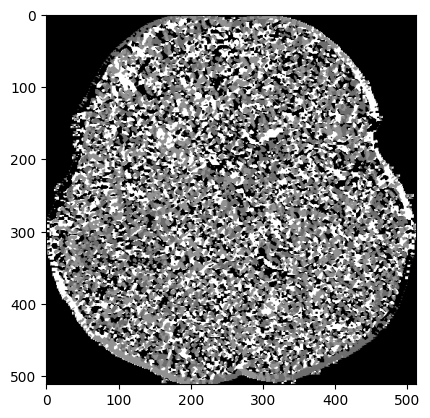

In [183]:
plt.imshow(O,cmap='gray')

In [1]:
import os
import cv2
from tqdm import tqdm
import numpy as np
from scipy import ndimage
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from scipy.ndimage import zoom
from sklearn.utils import shuffle
from scipy import signal
from xgboost import XGBClassifier
import pickle
from skimage.filters import threshold_otsu
from skimage.segmentation import clear_border
from skimage.morphology import closing, square
from scipy import ndimage
import matplotlib.patches as mpatches
from skimage.color import label2rgb
from skimage.measure import label, regionprops,find_contours
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from skimage.draw import polygon_perimeter
from math import pi, atan2, atan
from lazypredict.Supervised import LazyClassifier

def preprocessing(im1):
    im1[im1==255]=0
    im2 = cv2.medianBlur(im1,51)
    th,img2=cv2.threshold(im2, 10, 255, cv2.THRESH_BINARY)
    img2[img2==255]=1
    image=np.multiply(img2,im1)
    thresh = threshold_otsu(image)
    bw = closing(image > thresh, square(3))
    cleared = clear_border(bw)
    label_image = label(cleared)
    image_label_overlay = label2rgb(label_image, image=image, bg_label=0)
    contours = find_contours(image, 0.8)
    bounding_boxes = []
    
    for contour in contours:
        Xmin = np.min(contour[:,0])
        Xmax = np.max(contour[:,0])
        Ymin = np.min(contour[:,1])
        Ymax = np.max(contour[:,1])

        bounding_boxes.append([Xmin, Xmax, Ymin, Ymax])

    with_boxes  = np.copy(image)

    for box in bounding_boxes:
        #[Xmin, Xmax, Ymin, Ymax]
        r = [box[0],box[1],box[1],box[0], box[0]]
        c = [box[3],box[3],box[2],box[2], box[3]]
        rr, cc = polygon_perimeter(r, c, with_boxes.shape)
        with_boxes[rr, cc] = 5 #set color white
        
    #fig, ax = plt.subplots(figsize=(10, 6))
    poly=[]
    
    for region in regionprops(label_image):
        # take regions with large enough areas
        if region.area >= 10000:
                # draw rectangle around segmented coins
            minr, minc, maxr, maxc = region.bbox
            rect = mpatches.Rectangle((minc, minr), maxc - minc, maxr - minr,
                                          fill=False, edgecolor='red', linewidth=2)
            poly.append(region.bbox)
            #ax.add_patch(rect)

    try:
        a,b,c,d=poly[-1]
        return cv2.resize(image[a:c,b:d], (512,512), interpolation= cv2.INTER_LINEAR)
    except IndexError:
        return cv2.resize(image, (512,512), interpolation= cv2.INTER_LINEAR)

def wld_descriptor(image, num_orientations=8, num_diff_exc_bins=None, num_segments=6, num_bins_per_segment=3):
    """
    Compute the Weber Local Descriptor (WLD) for the given image.
    
    Args:
        image (numpy.ndarray): Input image.
        num_neighbors (int): Number of neighbors to consider for differential excitation.
        num_orientations (int): Number of dominant orientations to quantize the gradients.
        
    Returns:
        numpy.ndarray: WLD descriptor histogram.
    """
    # Compute differential excitation
    diff_excitation = differential_excitation(image,8)

    # Compute orientation
    orientation = structure_tensor_orientation(image,  num_orientations=8,window_size=3, sigma=1.0)

    # Replace NaN values in diff_excitation with a suitable value (e.g., 0)
    diff_excitation = np.nan_to_num(diff_excitation, nan=0.0)

    # Set default value for num_diff_exc_bins if None
    num_diff_exc_bins = num_diff_exc_bins or int(np.max(diff_excitation) - np.min(diff_excitation)) + 1

    wld_2d_hist = np.zeros((num_diff_exc_bins, num_orientations))
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            j = int(diff_excitation[y, x])
            t = int(orientation[y, x])
            wld_2d_hist[j, t] += 1

    # Encode the 2D histogram into the 1D histogram H
    wld_1d_hist = encode_2d_to_1d_histogram(wld_2d_hist, num_segments, num_bins_per_segment)

    return np.ravel(np.array(wld_2d_hist))

def encode_2d_to_1d_histogram(wld_2d_hist, num_segments, num_bins_per_segment):
    """
    Encode the 2D WLD histogram into a 1D histogram.

    Args:
        wld_2d_hist (numpy.ndarray): 2D WLD histogram.
        num_segments (int): Number of segments to divide the differential excitation range.
        num_bins_per_segment (int): Number of bins within each differential excitation segment.

    Returns:
        numpy.ndarray: 1D WLD descriptor histogram.
    """
    num_orientations = wld_2d_hist.shape[1]
    diff_exc_range = np.pi
    segment_width = diff_exc_range / num_segments

    # Divide each column (orientation) into segments and concatenate
    wld_1d_hist = []
    for t in range(num_orientations):
        column_hist = wld_2d_hist[:, t]
        segments = np.array_split(column_hist, num_segments)
        for segment in segments:
            if segment.size > 0:  # Check if segment is not empty
                segment_min = segment.min()
                segment_max = segment.max()
                segment_bins = np.linspace(segment_min, segment_max, num_bins_per_segment + 1, endpoint=True)
                segment_hist, _ = np.histogram(segment, bins=segment_bins, density=True)
                wld_1d_hist.extend(segment_hist)
            else:
                # If segment is empty, assign default values to the corresponding bins
                wld_1d_hist.extend([0.0] * num_bins_per_segment)

    return np.array(wld_1d_hist)

def differential_excitation(image, num_neighbors):
    """
    Compute the differential excitation component of the WLD descriptor.
    
    Args:
        image (numpy.ndarray): Input image.
        num_neighbors (int): Number of neighbors to consider.
        
    Returns:
        numpy.ndarray: Differential excitation values.
    """
    diff_excitation = np.zeros_like(image, dtype=np.float64)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            neighbors = []
            for dy in [-1, 0, 1]:
                for dx in [-1, 0, 1]:
                    if dy == dx == 0:
                        continue
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < image.shape[0] and 0 <= nx < image.shape[1]:
                        neighbors.append(image[ny, nx])
            neighbors = np.array(neighbors)
            diff_excitation[y, x] = np.arctan(np.sum(neighbors - image[y, x]) / (image[y, x]+1e-6))
    return diff_excitation

def structure_tensor_orientation(image, num_orientations=8,window_size=3, sigma=1.0):
    """
    Compute the orientation component of the WLD descriptor using the structure tensor approach.

    Args:
        image (numpy.ndarray): Input image.
        window_size (int): Size of the local neighborhood window for computing the structure tensor.
        sigma (float): Standard deviation for Gaussian kernel used for smoothing.

    Returns:
        numpy.ndarray: Orientations computed using the structure tensor.
    """
    image = np.uint8(image)
    # Compute gradients
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

    # Compute structure tensor components
    ix2 = sobel_x ** 2
    iy2 = sobel_y ** 2
    ixy = sobel_x * sobel_y

    # Smooth the structure tensor components
    kernel = cv2.getGaussianKernel(window_size, sigma)
    ix2 = cv2.sepFilter2D(ix2, -1, kernel, kernel)
    iy2 = cv2.sepFilter2D(iy2, -1, kernel, kernel)
    ixy = cv2.sepFilter2D(ixy, -1, kernel, kernel)

    # Compute eigenvalues and orientations
    orientation = np.zeros_like(image, dtype=np.float64)
    num_orientations=8
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            tensor = np.array([[ix2[y, x], ixy[y, x]], [ixy[y, x], iy2[y, x]]])
            if tensor.shape != (2, 2):
                continue
            eigenvalues, eigenvectors = np.linalg.eig(tensor)
            orientation[y, x] = np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0])
    
    if num_orientations is not None:
        orientation = (orientation % (2 * pi)) * num_orientations / (2 * pi)
        return orientation.astype(int)
    else:
        return orientation

    
def resize_image(image, target_size=(512, 512)):
    resized_image = cv2.resize(image, target_size)
    return resized_image

def extract_patches(image, patch_size):
    patches = []
    height, width = image.shape[:2]
    for y in range(0, height - patch_size[0] + 1, patch_size[0]):
        for x in range(0, width - patch_size[1] + 1, patch_size[1]):
            patch = image[y:y+patch_size[0], x:x+patch_size[1]]
            patches.append(patch)
    return np.array(patches)

def get_label(dir):
    if 'NS' in dir:
        return 0
    elif 'AS' in dir:
        return 1
    elif 'CS' in dir:
        return 2

def wld_descriptor_multiscale(image):
    num_orientations=8
    num_diff_exc_bins=None
    num_segments=6
    num_bins_per_segment=3
    num_scales=4
    """
    Compute the Weber Local Descriptor (WLD) for the given image at multiple scales.

    Args:
        image (numpy.ndarray): Input image.
        num_orientations (int): Number of dominant orientations to quantize.
        num_diff_exc_bins (int, optional): Number of bins for differential excitation values.
            If None, it is set to the maximum intensity value in the image.
        num_segments (int): Number of segments to divide the differential excitation range.
        num_bins_per_segment (int): Number of bins within each differential excitation segment.
        num_scales (int): Number of scales to compute the WLD descriptor.

    Returns:
        numpy.ndarray: 1D concatenated multi-scale WLD descriptor histogram.
    """
    # Create a Gaussian pyramid for the input image
    pyramid = [image.astype(np.float32)]  # Add the original image as the first level
    for _ in range(num_scales - 1):
        pyramid.append(cv2.pyrDown(pyramid[-1]))

    # Compute WLD descriptor at each scale and concatenate
    wld_descriptors = []
    for img in pyramid:
        #print('check',num_orientations)
        wld_descriptors.append(wld_descriptor(image, num_orientations=8, num_diff_exc_bins=None, num_segments=6, num_bins_per_segment=3))

    wld_multiscale = np.concatenate(wld_descriptors)
    return wld_multiscale
'''
print('Testing structure tensor')
print('\nTest sampling beings..')
dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test'
folders=np.random.choice(os.listdir(dirpath),40)
images=[]
X_test=np.zeros(shape=(100,64))
y_test=[]
c=0
while c<100:
    n=np.random.choice(folders,1)
    imgchoice=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
    img=preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],imgchoice[0]),0),(512,512)))
    patches=extract_patches(img,(256,256))
    w=np.concatenate((wld_descriptor(patches[0]),wld_descriptor(patches[1]),
                                    wld_descriptor(patches[2]),wld_descriptor(patches[3])))
    #w=wld_descriptor(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
    X_test[c,0:len(w)]=w
    y_test.append(get_label(n[0]))
    if c!=100:
        c+=1
    if c>100:
        break
    

print('Train sampling beings..')
dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train'
folders=np.random.choice(os.listdir(dirpath),10)
images=[]
X_train=np.zeros(shape=(150,64))
y_train=[]
a,no,c,N=0,0,0,0
while N<150:
    if N>150:
        break
    if N!=150:
        N+=1
    n=np.random.choice(folders,1)
    y_train.append(get_label(n[0]))
    if 'AS' in n[0] and a<50:
        imgchoice=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
        img=preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],imgchoice[0]),0),(512,512)))
        patches=extract_patches(img,(256,256))
        w=np.concatenate((wld_descriptor(patches[0]),wld_descriptor(patches[1]),
                                    wld_descriptor(patches[2]),wld_descriptor(patches[3])))
        #w=wld_descriptor(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
        X_train[N,0:len(w)]=w 
        a+=1
    elif 'NS' in n[0] and no<50:
        imgchoice=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
        img=preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],imgchoice[0]),0),(512,512)))
        patches=extract_patches(img,(256,256))
        w=np.concatenate((wld_descriptor(patches[0]),wld_descriptor(patches[1]),
                                    wld_descriptor(patches[2]),wld_descriptor(patches[3])))
        #w=wld_descriptor(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
        X_train[N,0:len(w)]=w
        no+=1
    elif 'CS' in n[0] and c<50:
        imgchoice=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
        img=preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],imgchoice[0]),0),(512,512)))
        patches=extract_patches(img,(256,256))
        w=np.concatenate((wld_descriptor(patches[0]),wld_descriptor(patches[1]),
                                    wld_descriptor(patches[2]),wld_descriptor(patches[3])))
        #w=wld_descriptor(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
        X_train[N,0:len(w)]=w
        c+=1
    

clf=LazyClassifier(verbose=0,ignore_warnings=True)
models,predictions=clf.fit(X_train,X_test,y_train,y_test)
print(models)
'''

"\nprint('Testing structure tensor')\nprint('\nTest sampling beings..')\ndirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test'\nfolders=np.random.choice(os.listdir(dirpath),40)\nimages=[]\nX_test=np.zeros(shape=(100,64))\ny_test=[]\nc=0\nwhile c<100:\n    n=np.random.choice(folders,1)\n    imgchoice=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)\n    img=preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],imgchoice[0]),0),(512,512)))\n    patches=extract_patches(img,(256,256))\n    w=np.concatenate((wld_descriptor(patches[0]),wld_descriptor(patches[1]),\n                                    wld_descriptor(patches[2]),wld_descriptor(patches[3])))\n    #w=wld_descriptor(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))\n    X_test[c,0:len(w)]=w\n    y_test.append(get_label(n[0]))\n    if c!=100:\n        c+=1\n    if c>100:\n        break\n    \n\nprint('Train sampling beings..')\ndirpath='C:/Users/mahesh.inamdar/Des

In [86]:
X_train=np.zeros(shape=(4365,256))
X_test=np.ones(shape=(4365,1))
X=np.concatenate((X_train,X_test),axis=1)
X[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [ ]:
dir_train='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train/'
dir_test='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test/'
from tqdm import tqdm
for i in range(10):
    print('iteration',i)
    print('-----TRAIN-----')
    y_train = []
    X_train=np.zeros(shape=(4365,256))
    r.shuffle(os.listdir(dir_train))
    ntr=0
    for patients in tqdm(os.listdir(dir_train)):
        for filename in os.listdir(os.path.join(dir_train,patients)):
            img = preprocessing(resize_image(cv2.imread(os.path.join(dir_train, patients,filename), cv2.IMREAD_GRAYSCALE)))
            patches=extract_patches(img,(256,256))
            con=np.concatenate((wld_descriptor_multiscale(patches[0]),wld_descriptor_multiscale(patches[1]),
                                    wld_descriptor_multiscale(patches[2]),wld_descriptor_multiscale(patches[3])))
            X_train[ntr,0:len(con)]= con
            y_train.append(get_label(patients))
            ntr+=1
                
    print('-----TEST-----')
    X_test=np.zeros(shape=(485,256))
    nte=0
    y_test = []
    r.shuffle(os.listdir(dir_test))
    for patients in tqdm(os.listdir(dir_test)):
        for filename in os.listdir(os.path.join(dir_test,patients)):
            img = preprocessing(resize_image(cv2.imread(os.path.join(dir_test, patients,filename), cv2.IMREAD_GRAYSCALE)))
            patches=extract_patches(img,(256,256))
            con=np.concatenate((wld_descriptor_multiscale(patches[0]),wld_descriptor_multiscale(patches[1]),
                                    wld_descriptor_multiscale(patches[2]),wld_descriptor_multiscale(patches[3])))
            X_test[nte,0:len(con)]= con
            y_test.append(get_label(patients))
            nte+=1
    
    clf=LazyClassifier(verbose=0,ignore_warnings=True)
    models,predictions=clf.fit(X_train,X_test,y_train,y_test)
    print(models)
    y_train=np.reshape(y_train,(4365,1))
    y_test=np.reshape(y_test,(485,1))
    Train=np.concatenate((X_train,y_train),axis=1)
    Test=np.concatenate((X_test,y_test),axis=1)
    np.savetxt('C:/Users/mahesh.inamdar/Desktop/codes/classes/run/' + str(i) + 'train.csv', Train, delimiter=',')
    np.savetxt('C:/Users/mahesh.inamdar/Desktop/codes/classes/run/' + str(i) + 'test.csv', Test, delimiter=',')

iteration 0
-----TRAIN-----


Processing:   0%|                                                                             | 0/2527 [00:00<?, ?it/s]

In [ ]:
import multiprocessing as mp
from tqdm import tqdm

dir_train = 'C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train/'
dir_test = 'C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test/'

def process_patient(patient_dir, mode):
    X = []
    y = []
    for filename in os.listdir(os.path.join(patient_dir, patient)):
        img = preprocessing(resize_image(cv2.imread(os.path.join(patient_dir, patient, filename), cv2.IMREAD_GRAYSCALE)))
        patches = extract_patches(img, (256, 256))
        con = np.concatenate((wld_descriptor_multiscale(patches[0]), wld_descriptor_multiscale(patches[1]),
                               wld_descriptor_multiscale(patches[2]), wld_descriptor_multiscale(patches[3])))
        X.append(con)
        y.append(get_label(patient))
    return X, y

for i in range(10):
    print('iteration', i)
    print('-----TRAIN-----')
    pool = mp.Pool(processes=mp.cpu_count())
    results = []
    for patient in tqdm(os.listdir(dir_train)):
        result = pool.apply_async(process_patient, args=(os.path.join(dir_train, patient), 'train'))
        results.append(result)
    pool.close()
    pool.join()

    y_train = []
    X_train = np.zeros(shape=(sum(len(r.get()[1]) for r in results), 256))
    ntr = 0
    for result in results:
        X, y = result.get()
        X_train[ntr:ntr+len(X), :] = np.stack(X)
        y_train.extend(y)
        ntr += len(X)

    print('-----TEST-----')
    pool = mp.Pool(processes=mp.cpu_count())
    results = []
    for patient in tqdm(os.listdir(dir_test)):
        result = pool.apply_async(process_patient, args=(os.path.join(dir_test, patient), 'test'))
        results.append(result)
    pool.close()
    pool.join()

    y_test = []
    X_test = np.zeros(shape=(sum(len(r.get()[1]) for r in results), 256))
    nte = 0
    for result in results:
        X, y = result.get()
        X_test[nte:nte+len(X), :] = np.stack(X)
        y_test.extend(y)
        nte += len(X)


iteration 0
-----TRAIN-----


100%|██████████████████████████████████████████████████████████████████████████████████████████| 49/49 [00:00<?, ?it/s]


In [ ]:
t=0
for i in os.listdir(dir_test):
    t+=len(os.listdir(os.path.join(dir_test,i)))
print(t)

In [110]:
clf=LazyClassifier(verbose=0,ignore_warnings=False)
models,predictions=clf.fit(X_train,X_test,y_train,y_test)
print(models)

 14%|███████████▍                                                                       | 4/29 [00:10<01:10,  2.84s/it]

CategoricalNB model failed to execute
Negative values in data passed to CategoricalNB (input X)


 66%|█████████████████████████████████████████████████████▋                            | 19/29 [00:18<00:05,  1.89it/s]

NuSVC model failed to execute
specified nu is infeasible


 90%|█████████████████████████████████████████████████████████████████████████▌        | 26/29 [00:21<00:01,  1.93it/s]

StackingClassifier model failed to execute
__init__() missing 1 required positional argument: 'estimators'


 97%|███████████████████████████████████████████████████████████████████████████████▏  | 28/29 [00:23<00:00,  1.78it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006410 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 36174
[LightGBM] [Info] Number of data points in the train set: 4365, number of used features: 192
[LightGBM] [Info] Start training from score -0.495668
[LightGBM] [Info] Start training from score -1.643221
[LightGBM] [Info] Start training from score -1.622118


100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:25<00:00,  1.16it/s]

                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
KNeighborsClassifier               0.62               0.80     0.61      0.75   
SVC                                0.61               0.79     0.59      0.76   
NearestCentroid                    0.64               0.79     0.77      0.73   
BernoulliNB                        0.58               0.75     0.72      0.68   
LabelSpreading                     0.52               0.74     0.50      0.66   
LabelPropagation                   0.52               0.74     0.50      0.66   
ExtraTreeClassifier                0.51               0.74     0.52      0.64   
RandomForestClassifier             0.45               0.71     0.43      0.60   
ExtraTreesClassifier               0.44               0.70     0.42      0.59   
LGBMClassifier                     0.42               0.69     0.41      0.57   
DecisionTreeClassifier      

In [106]:
y_train = np.zeros(shape=4365)
i=0
for patients in tqdm(os.listdir(dir_train)):
    for filename in os.listdir(os.path.join(dir_train,patients)):
        y_train[i]=get_label(patients)
        i+=1

100%|████████████████████████████████████████████████████████████████████████████████| 49/49 [00:00<00:00, 2124.91it/s]


In [111]:
y_train=np.reshape(y_train,(4365,1))
y_test=np.reshape(y_test,(485,1))
Train=np.concatenate((X_train,y_train),axis=1)
Test=np.concatenate((X_test,y_test),axis=1)
np.savetxt('C:/Users/mahesh.inamdar/Desktop/codes/classes/run/' + str(i) + 'train.csv', Train, delimiter=',')
np.savetxt('C:/Users/mahesh.inamdar/Desktop/codes/classes/run/' + str(i) + 'test.csv', Test, delimiter=',')

In [69]:
dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train'
folders=np.random.choice(os.listdir(dirpath),40)
images=[]
X_train=np.zeros(shape=(200,256))
y_train=[]
c=0
while c<=200:
    if c>200:
        break
    n=np.random.choice(folders,1)
    imgchoice=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
    img=preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],imgchoice[0]),0),(512,512)))
    patches=extract_patches(img,(256,256))
    w=np.concatenate((wld_descriptor_multiscale(patches[0]),wld_descriptor_multiscale(patches[1]),
                                    wld_descriptor_multiscale(patches[2]),wld_descriptor_multiscale(patches[3])))
    print(np.shape(w))
    X_train[c,0:len(w)]=w
    y_train.append(get_label(n[0]))
    c+=1

(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(128,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)
(256,)

IndexError: index 200 is out of bounds for axis 0 with size 200

In [70]:
for i in range(10):
    dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train'
    folders=np.random.choice(os.listdir(dirpath),40)
    images=[]
    X_train=np.zeros(shape=(200,256))
    y_train=[]
    c=0
    while c<=200:
        if c>200:
            break
        n=np.random.choice(folders,1)
        imgchoice=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
        img=preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],imgchoice[0]),0),(512,512)))
        patches=extract_patches(img,(256,256))
        w=np.concatenate((wld_descriptor_multiscale(patches[0]),wld_descriptor_multiscale(patches[1]),
                                        wld_descriptor_multiscale(patches[2]),wld_descriptor_multiscale(patches[3])))
        print(np.shape(w))
        X_train[c,0:len(w)]=w
        y_train.append(get_label(n[0]))
        c+=1
    
    
    dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test'
    folders=np.random.choice(os.listdir(dirpath),40)
    images=[]
    X_test=np.zeros(shape=(50,256))
    y_test=[]
    c=0
    while c<=50:
        if c>50:
            break
        n=np.random.choice(folders,1)
        imgchoice=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
        img=preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],imgchoice[0]),0),(512,512)))
        patches=extract_patches(img,(256,256))
        w=np.concatenate((wld_descriptor(patches[0]),wld_descriptor(patches[1]),
                                        wld_descriptor(patches[2]),wld_descriptor(patches[3])))
        X_test[c,0:len(w)]=w
        y_test.append(get_label(n[0]))
        c+=1

IndexError: index 50 is out of bounds for axis 0 with size 50

In [71]:
clf=LazyClassifier(verbose=0,ignore_warnings=True)
models,predictions=clf.fit(X_train,X_test,y_train,y_test)
print(models)

 97%|███████████████████████████████████████████████████████████████████████████████▏  | 28/29 [00:01<00:00, 15.81it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001593 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8724
[LightGBM] [Info] Number of data points in the train set: 200, number of used features: 176
[LightGBM] [Info] Start training from score -1.491655
[LightGBM] [Info] Start training from score -0.723606
[LightGBM] [Info] Start training from score -1.237874
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:02<00:00, 13.12it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
                         

In [ ]:
    dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train'
    folders=np.random.choice(os.listdir(dirpath),40)
    images=[]
    X_train=np.zeros(shape=(200,256))
    y_train=[]
    c=0
    while c<=200:
        if c>200:
            break
        n=np.random.choice(folders,1)
        imgchoice=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
        img=preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],imgchoice[0]),0),(512,512)))
        patches=extract_patches(img,(256,256))
        w=np.concatenate((wld_descriptor_multiscale(patches[0]),wld_descriptor_multiscale(patches[1]),
                                        wld_descriptor_multiscale(patches[2]),wld_descriptor_multiscale(patches[3])))
        print(np.shape(w))
        X_train[c,0:len(w)]=w
        y_train.append(get_label(n[0]))
        c+=1
    
    
    dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test'
    folders=np.random.choice(os.listdir(dirpath),40)
    images=[]
    X_test=np.zeros(shape=(50,256))
    y_test=[]
    c=0
    while c<=50:
        if c>50:
            break
        n=np.random.choice(folders,1)
        imgchoice=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
        img=preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],imgchoice[0]),0),(512,512)))
        patches=extract_patches(img,(256,256))
        w=np.concatenate((wld_descriptor(patches[0]),wld_descriptor(patches[1]),
                                        wld_descriptor(patches[2]),wld_descriptor(patches[3])))
        X_test[c,0:len(w)]=w
        y_test.append(get_label(n[0]))
        c+=1

In [23]:
import numpy as np
import cv2

def differential_excitation(img, kernel_size=5, sigma=1.0):
    """
    Compute differential excitation based on the Gaussian kernel.
    """
    # Compute gradient images
    grad_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=kernel_size)
    grad_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=kernel_size)

    # Compute differential excitation
    diff_excitation = np.sqrt(grad_x ** 2 + grad_y ** 2)

    # Apply Gaussian smoothing
    diff_excitation = cv2.GaussianBlur(diff_excitation, (kernel_size, kernel_size), sigma)

    return diff_excitation

def structure_tensor(img, kernel_size=5, sigma=1.0):
    """
    Compute the structure tensor for orientation estimation.
    """
    # Compute gradient images
    grad_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=kernel_size)
    grad_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=kernel_size)

    # Compute structure tensor components
    grad_xx = grad_x ** 2
    grad_xy = grad_x * grad_y
    grad_yy = grad_y ** 2

    # Apply Gaussian smoothing
    grad_xx = cv2.GaussianBlur(grad_xx, (kernel_size, kernel_size), sigma)
    grad_xy = cv2.GaussianBlur(grad_xy, (kernel_size, kernel_size), sigma)
    grad_yy = cv2.GaussianBlur(grad_yy, (kernel_size, kernel_size), sigma)

    return grad_xx, grad_xy, grad_yy

def wld_orientation(img, kernel_size=5, sigma=1.0):
    """
    Compute orientation for the Weber Local Descriptor (WLD).
    """
    # Compute differential excitation
    diff_exc = differential_excitation(img, kernel_size, sigma)

    # Compute structure tensor components
    grad_xx, grad_xy, grad_yy = structure_tensor(img, kernel_size, sigma)

    # Compute orientation
    numerator = grad_yy - grad_xx
    denominator = 2 * grad_xy
    orientation = np.arctan2(numerator, denominator)

    return orientation, diff_exc

def wld_descriptor(image, num_orientations=8, num_diff_exc_bins=None, num_segments=6, num_bins_per_segment=3):
    """
    Compute the Weber Local Descriptor (WLD) for the given image.

    Args:
        image (numpy.ndarray): Input image.
        num_orientations (int): Number of dominant orientations to quantize the gradients.
        num_diff_exc_bins (int, optional): Number of differential excitation bins. If None, it is set to the maximum value of differential excitation plus 1.
        num_segments (int): Number of segments for the 1D histogram encoding.
        num_bins_per_segment (int): Number of bins per segment for the 1D histogram encoding.

    Returns:
        numpy.ndarray: WLD descriptor histogram.
    """

    # Compute differential excitation
    diff_excitation = differential_excitation(image)

    # Compute orientation
    orientation, _ = wld_orientation(image, kernel_size=3, sigma=1.0)

    # Replace NaN values in diff_excitation with a suitable value (e.g., 0)
    diff_excitation = np.nan_to_num(diff_excitation, nan=0.0)

    # Set default value for num_diff_exc_bins if None
    num_diff_exc_bins = num_diff_exc_bins or int(np.max(diff_excitation) - np.min(diff_excitation)) + 1

    wld_2d_hist = np.zeros((num_diff_exc_bins, num_orientations))

    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            j = int(diff_excitation[y, x])
            t = int(orientation[y, x])
            wld_2d_hist[j, t] += 1

    # Encode the 2D histogram into the 1D histogram H
    wld_1d_hist = encode_2d_to_1d_histogram(wld_2d_hist, num_segments, num_bins_per_segment)

    return wld_1d_hist
    
def extract_patches(image, patch_size):
    patches = []
    height, width = image.shape[:2]
    for y in range(0, height - patch_size[0] + 1, patch_size[0]):
        for x in range(0, width - patch_size[1] + 1, patch_size[1]):
            patch = image[y:y+patch_size[0], x:x+patch_size[1]]
            patches.append(patch)
    return np.array(patches)

def encode_2d_to_1d_histogram(wld_2d_hist, num_segments, num_bins_per_segment):
    """
    Encode the 2D histogram into a 1D histogram with a predefined number of segments and bins per segment.

    Args:
        wld_2d_hist (numpy.ndarray): 2D histogram of differential excitation and orientation.
        num_segments (int): Number of segments for the 1D histogram encoding.
        num_bins_per_segment (int): Number of bins per segment for the 1D histogram encoding.

    Returns:
        numpy.ndarray: 1D histogram encoding of the 2D histogram.
    """
    wld_1d_hist = np.zeros((num_segments, num_bins_per_segment))

    # Iterate over the 2D histogram and populate the 1D histogram
    for j in range(wld_2d_hist.shape[0]):
        for t in range(wld_2d_hist.shape[1]):
            segment_idx = j * num_segments // wld_2d_hist.shape[0]
            bin_idx = t * num_bins_per_segment // wld_2d_hist.shape[1]

            # Check if indices are within valid range
            if segment_idx < num_segments and bin_idx < num_bins_per_segment:
                wld_1d_hist[segment_idx, bin_idx] += wld_2d_hist[j, t]

    return wld_1d_hist.ravel()

In [21]:
img=preprocessing(resize_image(cv2.imread('C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train/AS_01_thin/Anonymize.Seq3.Ser202.Img145.jpg',0),(512,512)))
w=wld_descriptor(img,num_orientations=8, num_diff_exc_bins=None, num_segments=6, num_bins_per_segment=3)

In [24]:
print('Testing structure tensor')
print('\nTest sampling beings..')
dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test'
folders=np.random.choice(os.listdir(dirpath),40)
images=[]
X_test=np.zeros(shape=(100,18))
y_test=[]
c=0
while c<100:
    n=np.random.choice(folders,1)
    img=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
    w=wld_descriptor(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
    X_test[c,0:len(w)]=w
    y_test.append(get_label(n[0]))
    if c!=100:
        c+=1
    if c>100:
        break
    

print('Train sampling beings..')
dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train'
folders=np.random.choice(os.listdir(dirpath),10)
images=[]
X_train=np.zeros(shape=(1200,18))
y_train=[]
a,no,c,N=0,0,0,0
while N<1200:
    if N>1200:
        break
    if N!=1200:
        N+=1
    n=np.random.choice(folders,1)
    y_train.append(get_label(n[0]))
    if 'AS' in n[0] and a<400:
        img=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
        w=wld_descriptor(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
        X_train[N,0:len(w)]=w 
        a+=1
    elif 'NS' in n[0] and no<400:
        img=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
        w=wld_descriptor(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
        X_train[N,0:len(w)]=w
        no+=1
    elif 'CS' in n[0] and c<400:
        img=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
        w=wld_descriptor(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
        X_train[N,0:len(w)]=w
        c+=1
    

clf=LazyClassifier(verbose=0,ignore_warnings=True)
models,predictions=clf.fit(X_train,X_test,y_train,y_test)
print(models)

Testing structure tensor

Test sampling beings..
Train sampling beings..


 90%|█████████████████████████████████████████████████████████████████████████▌        | 26/29 [00:01<00:00, 22.95it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000396 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3657
[LightGBM] [Info] Number of data points in the train set: 1200, number of used features: 18
[LightGBM] [Info] Start training from score -0.930981
[LightGBM] [Info] Start training from score -0.679902
[LightGBM] [Info] Start training from score -2.310953


100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:02<00:00, 11.67it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
                               Accuracy  Balanced Accuracy ROC AUC  F1 Score  \
Model                                                                          
PassiveAggressiveClassifier        0.51               0.59    None      0.50   
QuadraticDiscriminantAnalysis      0.33               0.44    None      0.32   
Perceptron                         0.27               0.39    None      0.24   
LinearDiscriminantAnalysis         0.21               0.38    None      0.14   
LinearSVC                          0.20               0.37    None      0.12   
SVC                                0.20               0.37    None      0.13   
RidgeClassifier                    0.20               0.37    None      0.12   
LogisticRegression                 0.20               0.37    None      0.12   
CalibratedClassifierCV             0.19               0.36    None      0.11   
RidgeClassifierCV                  0.19      

In [32]:
def wld_descriptor(image):
    num_orientations=8
    num_diff_exc_bins=None
    num_segments=6
    num_bins_per_segment=3
    """
    Compute the Weber Local Descriptor (WLD) for the given image.
    
    Args:
        image (numpy.ndarray): Input image.
        num_neighbors (int): Number of neighbors to consider for differential excitation.
        num_orientations (int): Number of dominant orientations to quantize the gradients.
        
    Returns:
        numpy.ndarray: WLD descriptor histogram.
    """
    # Compute differential excitation
    diff_excitation = differential_excitation(image,8)

    # Compute orientation
    orientation = structure_tensor_orientation(image,  num_orientations=8,window_size=3, sigma=1.0)

    # Replace NaN values in diff_excitation with a suitable value (e.g., 0)
    diff_excitation = np.nan_to_num(diff_excitation, nan=0.0)

    # Set default value for num_diff_exc_bins if None
    num_diff_exc_bins = num_diff_exc_bins or int(np.max(diff_excitation) - np.min(diff_excitation)) + 1

    wld_2d_hist = np.zeros((num_diff_exc_bins, num_orientations))
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            j = int(diff_excitation[y, x])
            t = int(orientation[y, x])
            wld_2d_hist[j, t] += 1

    # Encode the 2D histogram into the 1D histogram H
    #wld_1d_hist = encode_2d_to_1d_histogram(wld_2d_hist, num_segments, num_bins_per_segment)

    return np.ravel(np.array(wld_2d_hist))

def encode_2d_to_1d_histogram(wld_2d_hist, num_segments, num_bins_per_segment):
    """
    Encode the 2D WLD histogram into a 1D histogram.

    Args:
        wld_2d_hist (numpy.ndarray): 2D WLD histogram.
        num_segments (int): Number of segments to divide the differential excitation range.
        num_bins_per_segment (int): Number of bins within each differential excitation segment.

    Returns:
        numpy.ndarray: 1D WLD descriptor histogram.
    """
    num_orientations = wld_2d_hist.shape[1]
    diff_exc_range = np.pi
    segment_width = diff_exc_range / num_segments

    # Divide each column (orientation) into segments and concatenate
    wld_1d_hist = []
    for t in range(num_orientations):
        column_hist = wld_2d_hist[:, t]
        segments = np.array_split(column_hist, num_segments)
        for segment in segments:
            if segment.size > 0:  # Check if segment is not empty
                segment_min = segment.min()
                segment_max = segment.max()
                segment_bins = np.linspace(segment_min, segment_max, num_bins_per_segment + 1, endpoint=True)
                segment_hist, _ = np.histogram(segment, bins=segment_bins, density=True)
                wld_1d_hist.extend(segment_hist)
            else:
                # If segment is empty, assign default values to the corresponding bins
                wld_1d_hist.extend([0.0] * num_bins_per_segment)

    return np.array(wld_1d_hist)

def differential_excitation(image, num_neighbors):
    """
    Compute the differential excitation component of the WLD descriptor.
    
    Args:
        image (numpy.ndarray): Input image.
        num_neighbors (int): Number of neighbors to consider.
        
    Returns:
        numpy.ndarray: Differential excitation values.
    """
    diff_excitation = np.zeros_like(image, dtype=np.float64)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            neighbors = []
            for dy in [-1, 0, 1]:
                for dx in [-1, 0, 1]:
                    if dy == dx == 0:
                        continue
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < image.shape[0] and 0 <= nx < image.shape[1]:
                        neighbors.append(image[ny, nx])
            neighbors = np.array(neighbors)
            diff_excitation[y, x] = np.arctan(np.sum(neighbors - image[y, x]) / (image[y, x]+1e-6))
    return diff_excitation

def structure_tensor_orientation(image, num_orientations=8,window_size=3, sigma=1.0):
    """
    Compute the orientation component of the WLD descriptor using the structure tensor approach.

    Args:
        image (numpy.ndarray): Input image.
        window_size (int): Size of the local neighborhood window for computing the structure tensor.
        sigma (float): Standard deviation for Gaussian kernel used for smoothing.

    Returns:
        numpy.ndarray: Orientations computed using the structure tensor.
    """
    # Compute gradients
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

    # Compute structure tensor components
    ix2 = sobel_x ** 2
    iy2 = sobel_y ** 2
    ixy = sobel_x * sobel_y

    # Smooth the structure tensor components
    kernel = cv2.getGaussianKernel(window_size, sigma)
    ix2 = cv2.sepFilter2D(ix2, -1, kernel, kernel)
    iy2 = cv2.sepFilter2D(iy2, -1, kernel, kernel)
    ixy = cv2.sepFilter2D(ixy, -1, kernel, kernel)

    # Compute eigenvalues and orientations
    orientation = np.zeros_like(image, dtype=np.float64)
    num_orientations=8
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            tensor = np.array([[ix2[y, x], ixy[y, x]], [ixy[y, x], iy2[y, x]]])
            eigenvalues, eigenvectors = np.linalg.eig(tensor)
            orientation[y, x] = np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0])
    
    if num_orientations is not None:
        orientation = (orientation % (2 * pi)) * num_orientations / (2 * pi)
        return orientation.astype(int)
    else:
        return orientation.astype(int)

    
def resize_image(image, target_size=(512, 512)):
    resized_image = cv2.resize(image, target_size)
    return resized_image



def get_label(dir):
    if 'NS' in dir:
        return 0
    elif 'AS' in dir:
        return 1
    elif 'CS' in dir:
        return 2

In [33]:
for i in range(10):
    print('Checking Structure Orientation only WLD\n')
    print('Iteration number',i)
    print('Train sampling beings..')
    dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train'
    folders=np.random.choice(os.listdir(dirpath),10)
    images=[]
    X_train=np.zeros(shape=(3000,64))
    y_train=[]
    a,no,c,N=0,0,0,0
    while N<3000:
        if N>3000:
            break
        if N<3000:
            N+=1
        n=np.random.choice(folders,1)
        y_train.append(get_label(n[0]))
        if 'AS' in n[0] and a<1000:
            img=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
            w=wld_descriptor(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
            X_train[N,0:len(w)]=w
            a+=1
        elif 'NS' in n[0] and no<1000:
            img=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
            w=wld_descriptor(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
            X_train[N,0:len(w)]=w
            no+=1
        elif 'CS' in n[0] and c<1000:
            img=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
            w=wld_descriptor(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
            X_train[N,0:len(w)]=w
            c+=1
    
    
    
    print('Test sampling beings..')
    dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test'
    folders=np.random.choice(os.listdir(dirpath),40)
    images=[]
    X_test=np.zeros(shape=(100,64))
    y_test=[]
    c=0
    while c<100:
        n=np.random.choice(folders,1)
        img=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
        w=wld_descriptor(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
        X_test[c,0:len(w)]=w
        y_test.append(get_label(n[0]))
        if c!=100:
            c+=1
        if c>100:
            break
    
    clf=LazyClassifier(verbose=0,ignore_warnings=True)
    models,predictions=clf.fit(X_train,X_test,y_train,y_test)
    print(models)

Checking Structure Orientation only WLD

Iteration number 0
Train sampling beings..


IndexError: index 3000 is out of bounds for axis 0 with size 3000

In [40]:
clf=LazyClassifier(verbose=0,ignore_warnings=False)
models,predictions=clf.fit(X_train,X_test,y_train,y_test)
print(models)

 14%|███████████▍                                                                       | 4/29 [00:00<00:01, 14.93it/s]

AdaBoostClassifier model failed to execute
X has 18 features, but ColumnTransformer is expecting 64 features as input.
BaggingClassifier model failed to execute
X has 18 features, but ColumnTransformer is expecting 64 features as input.
BernoulliNB model failed to execute
X has 18 features, but ColumnTransformer is expecting 64 features as input.
CalibratedClassifierCV model failed to execute
X has 18 features, but ColumnTransformer is expecting 64 features as input.
CategoricalNB model failed to execute
X has 18 features, but ColumnTransformer is expecting 64 features as input.
DecisionTreeClassifier model failed to execute
X has 18 features, but ColumnTransformer is expecting 64 features as input.
DummyClassifier model failed to execute
X has 18 features, but ColumnTransformer is expecting 64 features as input.
ExtraTreeClassifier model failed to execute
X has 18 features, but ColumnTransformer is expecting 64 features as input.


 31%|█████████████████████████▊                                                         | 9/29 [00:00<00:01, 18.29it/s]

ExtraTreesClassifier model failed to execute
X has 18 features, but ColumnTransformer is expecting 64 features as input.
GaussianNB model failed to execute
X has 18 features, but ColumnTransformer is expecting 64 features as input.
KNeighborsClassifier model failed to execute
X has 18 features, but ColumnTransformer is expecting 64 features as input.


 41%|█████████████████████████████████▉                                                | 12/29 [00:00<00:01, 15.88it/s]

...

SVC model failed to execute
X has 18 features, but ColumnTransformer is expecting 64 features as input.
StackingClassifier model failed to execute
__init__() missing 1 required positional argument: 'estimators'
XGBClassifier model failed to execute
X has 18 features, but ColumnTransformer is expecting 64 features as input.


 97%|███████████████████████████████████████████████████████████████████████████████▏  | 28/29 [00:01<00:00, 14.19it/s]

[LightGBM] [Info] Number of positive: 2390, number of negative: 610
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000665 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2134
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.796667 -> initscore=1.365590
[LightGBM] [Info] Start training from score 1.365590


100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:02<00:00, 12.13it/s]

LGBMClassifier model failed to execute
X has 18 features, but ColumnTransformer is expecting 64 features as input.
Empty DataFrame
Columns: [Accuracy, Balanced Accuracy, ROC AUC, F1 Score, Time Taken]
Index: []


In [44]:
X_train,X_test,y_train,y_test=train_test_split(X_train,y_train,test_size=0.2)

In [45]:
clf=LazyClassifier(verbose=0,ignore_warnings=False)
models,predictions=clf.fit(X_train,X_test,y_train,y_test)
print(models)

 55%|█████████████████████████████████████████████▏                                    | 16/29 [00:01<00:01, 12.57it/s]

NuSVC model failed to execute
specified nu is infeasible


 97%|███████████████████████████████████████████████████████████████████████████████▏  | 28/29 [00:01<00:00, 14.23it/s]

StackingClassifier model failed to execute
__init__() missing 1 required positional argument: 'estimators'
[LightGBM] [Info] Number of positive: 1914, number of negative: 486
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000634 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2115
[LightGBM] [Info] Number of data points in the train set: 2400, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.797500 -> initscore=1.370742
[LightGBM] [Info] Start training from score 1.370742


100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:02<00:00, 11.87it/s]

                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
KNeighborsClassifier               0.52               0.52     0.52      0.57   
PassiveAggressiveClassifier        0.53               0.51     0.51      0.57   
NearestCentroid                    0.51               0.51     0.51      0.56   
XGBClassifier                      0.78               0.51     0.51      0.71   
LGBMClassifier                     0.78               0.51     0.51      0.71   
RandomForestClassifier             0.78               0.50     0.50      0.71   
QuadraticDiscriminantAnalysis      0.23               0.50     0.50      0.12   
LabelPropagation                   0.79               0.50     0.50      0.70   
LabelSpreading                     0.79               0.50     0.50      0.70   
DecisionTreeClassifier             0.75               0.50     0.50      0.70   
GaussianNB                  